# Plot joint figures
Figures that use the Group 1 and the Group 2 data from the merged dataset

## Paths and set-up

In [3]:
from pathlib import Path

import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import ScalarFormatter
from scipy.stats import sem

# =============================================================================
# PATHS
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "test"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREPARED_FILE = DATA_DIR / "merged_data.csv"

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

RANDOM_SEED = 12345

rng = np.random.default_rng(RANDOM_SEED)

# =============================================================================
# VIRUSES
# =============================================================================

viruses = ["1918_H1", "1934_H1", "1977_H1", "2006_H1", "2018_H1", 
           "1966_H2", 
           "1968_H3", "1972_H3", "1982_H3", "1991_H3", "2004_H3", "2019_H3", 
           "2004_Vietnam_H5", "2005_Qinghai_H5", "2022_H5", 
           "2003_H7", "2013_H7", 
           "2014_H9",
]

virus_labels = {
    "1968_H3": "A/Memphis/1/1968 H3N2",
    "1972_H3": "A/Udorn/307/1972 H3N2",
    "1982_H3": "A/Netherlands/233/1982 H3N2",
    "1991_H3": "A/UK/261/1991 H3N2",
    "2004_H3": "A/New York/55/2004 H3N2",
    "2019_H3": "A/South Australia/34/2019 H3N2",
    "2003_H7": "A/New York/107/2003 H7N2",
    "2013_H7": "A/Shanghai/1/2013 H7N9",
    "1918_H1": "A/South Carolina/1/1918 H1N1",
    "1934_H1": "A/PR/8/1934 H1N1",
    "1977_H1": "A/USSR/90/1977 H1N1",
    "2006_H1": "A/Solomon Islands/3/2006 H1N1",
    "2018_H1": "A/Brisbane/2/2018 H1N1",
    "2004_Vietnam_H5": "A/Vietnam/1203/2004 H5N1",
    "2005_Qinghai_H5": "A/bar-headed goose/Qinghai/3/2005 H5N1",
    "2022_H5": "A/mute swan/England/117298/2022 H5N1",
    "2014_H9": "A/Hong Kong/308/2014 H9N2",
    "1966_H2": "A/England/1/1966 H2N2",
}

# =============================================================================
# COLOURS
# =============================================================================

pastel_colors = {
    "H3N2": "#cab2d6",
    "H7N2": "#fdbf6f",
    "H7N9": "#fdbf6f",
    "H5N1": "#b2df8a",
    "H1N1": "#9ecae1",
    "H2N2": "#fb9a99",
    "H9N2": "#D3D3D3",
}

darker_colors = {
    "H3N2": "purple",
    "H7N2": "#fc8d59",
    "H7N9": "#fc8d59",
    "H5N1": "#74c476",
    "H1N1": "#9ecae1",
    "H2N2": "#fb9a99",
    "H9N2": "grey",
}

def get_pastel_color(virus, palette):
    """Return colour based on influenza subtype."""
    if "_H1" in virus:
        return palette["H1N1"]
    if "_H2" in virus:
        return palette["H2N2"]
    if "_H3" in virus:
        return palette["H3N2"]
    if "_H5" in virus:
        return palette["H5N1"]
    if "_H7" in virus:
        return palette["H7N2"]
    if "_H9" in virus:
        return palette["H9N2"]
    return "#D3D3D3"

colors = [
    get_pastel_color(virus, pastel_colors,)
    for virus in viruses
]

## Load data

In [4]:
# =============================================================================
# LOAD DATA
# =============================================================================

print("\n" + "=" * 70)
print("Loading data")
print("=" * 70)

df = pd.read_csv(PREPARED_FILE)

merged_df = df.copy()

print(
    f"Dataset contains "
    f"{merged_df.shape[0]} rows and "
    f"{merged_df.shape[1]} columns."
)


Loading data
Dataset contains 1004 rows and 21 columns.


## Proportion neutralising

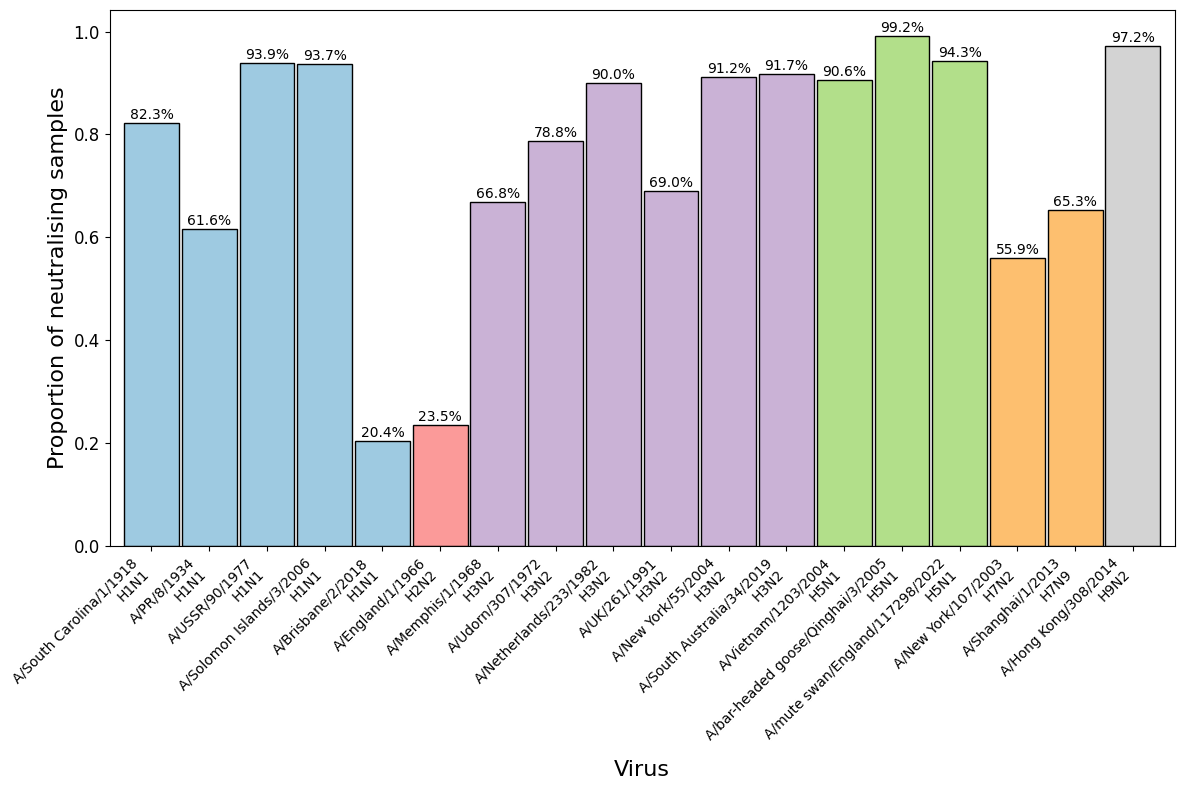

In [5]:
# Calculate the proportion of samples with IC50 > 42 for each virus
NEUTRALISING_THRESHOLD = 42

proportion_above_threshold = {}

for virus in viruses:

    total_samples = (
        merged_df[virus]
        .notna()
        .sum()
    )

    above_threshold = (
        merged_df[virus]
        > NEUTRALISING_THRESHOLD
    ).sum()

    proportion_above_threshold[virus] = (
        above_threshold / total_samples
        if total_samples > 0
        else 0
    )

proportion_above_threshold = pd.Series(proportion_above_threshold)

# Plot figure
plt.figure(figsize=(12, 8))

ax = proportion_above_threshold.plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    width=0.95,
)

plt.ylabel(
    "Proportion of neutralising samples",
    fontsize=16,
)

plt.xlabel(
    "Virus",
    fontsize=16,
)

# Set x-tick labels with virus_labels, split line for subtype
plt.xticks(
    ticks=range(
        len(proportion_above_threshold.index)
    ),
    labels=[
        virus_labels[virus].rsplit(" ", 1,)[0]
        + "\n"
        + virus_labels[virus].rsplit(" ", 1,)[1]
        if (
            " " in virus_labels[virus]
            and any(
                subtype in virus_labels[virus]
                for subtype in ["H1N1", "H2N2", "H3N2", 
                                "H5N1", "H7N2", "H7N9", "H9N2",
                ]
            )
        )
        else virus_labels[virus]
        for virus
        in proportion_above_threshold.index
    ],
    rotation=45,
    ha="right",
    fontsize=10,
)

plt.yticks(fontsize=12)

# Add percentage above each bar
for i, virus in enumerate(proportion_above_threshold.index):
    percent = (100 * proportion_above_threshold[virus]
    )
    ax.text(i, proportion_above_threshold[virus] + 0.002,
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "proportion_neutralizing.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## IC50 boxplot

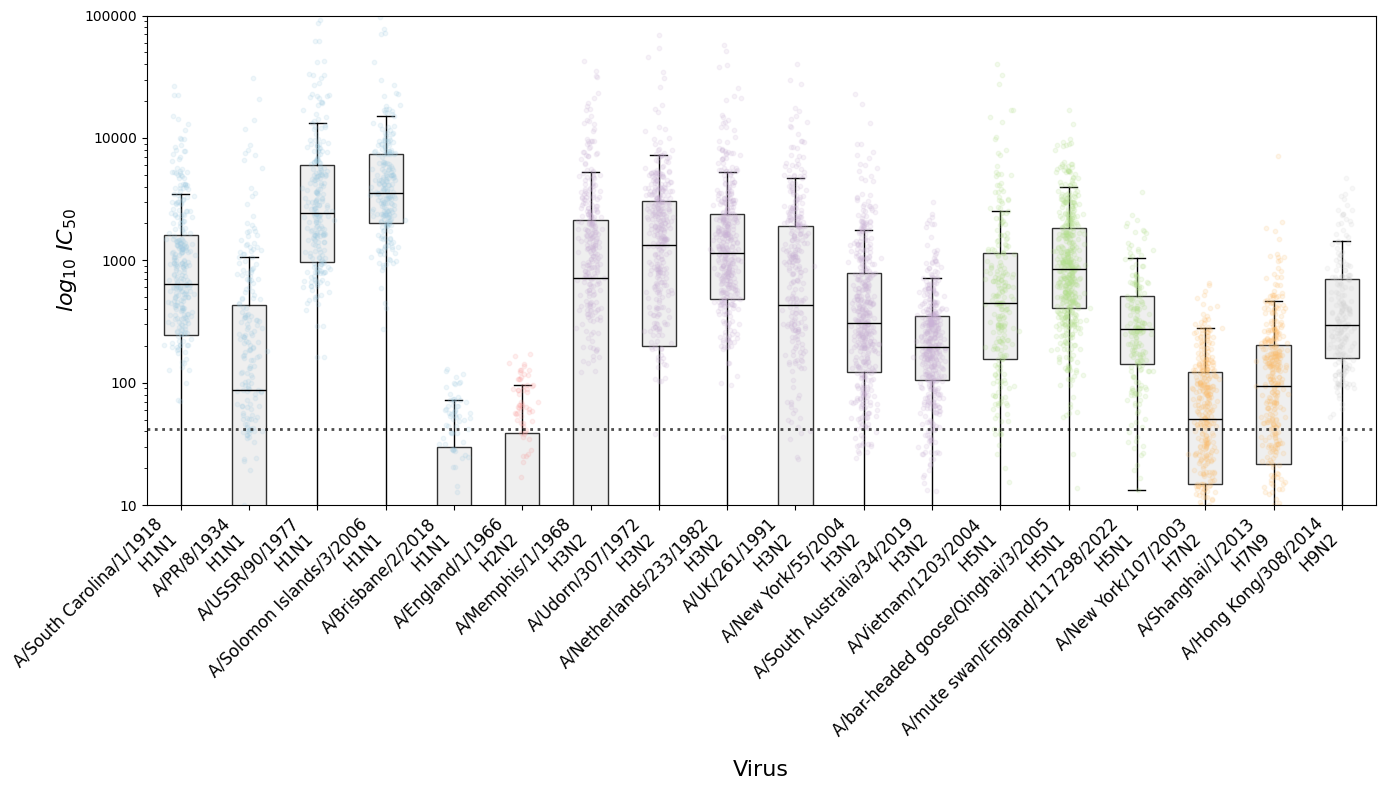

In [6]:
boxplot_data = [
    merged_df[virus].dropna()
    for virus in viruses
]

plt.figure(figsize=(14, 8))

# Boxplot with grey boxes
box = plt.boxplot(
    boxplot_data,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(
        facecolor="#EBEBEB",
        edgecolor="black",
        alpha=0.8,
    ),
)

# Set median line to black
for median in box["medians"]:
    median.set_color("black")

# Show individual data points underneath the boxplot, coloured by virus type, with random jitter
for i, data in enumerate(boxplot_data):
    x = rng.normal(
        loc=i + 1,
        scale=0.08,
        size=len(data),
    )
    plt.scatter(x, data,
        color=colors[i],
        alpha=0.15,
        s=10,
        zorder=2,
    )

plt.yscale("log")

plt.ylabel(
    "$log_{10}$ $IC_{50}$",
    fontsize=16,
)

plt.xlabel(
    "Virus",
    fontsize=16,
)

# Set x-tick labels with virus_labels, split line for subtype
plt.xticks(
    ticks=range(
        1,
        len(viruses) + 1,
    ),
    labels=[
        virus_labels[virus].rsplit(" ", 1,)[0]
        + "\n"
        + virus_labels[virus].rsplit(" ", 1,)[1]
        if (
            " " in virus_labels[virus]
            and any(
                subtype in virus_labels[virus]
                for subtype in ["H1N1", "H2N2", "H3N2", 
                                "H5N1", "H7N2", "H7N9", "H9N2",
                ]
            )
        )
        else virus_labels[virus]
        for virus in viruses
    ],
    rotation=45,
    ha="right",
    fontsize=12,
)

plt.ylim(10, 100000,)

plt.axhline(
    NEUTRALISING_THRESHOLD,
    color="black",
    linestyle=":",
    linewidth=2,
    alpha=0.7,
)

plt.gca().yaxis.set_major_formatter(
    ScalarFormatter()
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "IC50_Boxplot.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## LOWESS
### Year of circulation

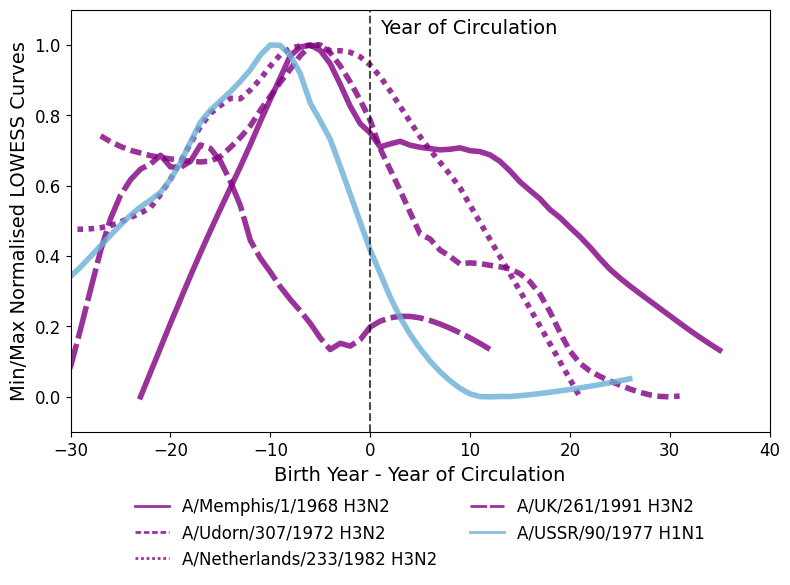

In [7]:
figsize = (8, 6)
label_fontsize = 14
title_fontsize = 16
legend_fontsize = 12
legend_loc = "upper center"
legend_bbox = (0.5, -0.12)
legend_ncol = 2
legend_frameon = False
tick_fontsize = 12

year_columns = [
    "1968_H3",
    "1972_H3",
    "1982_H3",
    "1991_H3",
    "1977_H1",
]

paired_colors = sns.color_palette(
    "Paired",
    len(year_columns),
)

line_styles = [
    '-',            # solid
    (0, (2, 1)),    # short dash, short gap
    (0, (1, 1)),    # very compact dots
    (0, (6, 1)),    # very long dash, short gap
    '-',
]


plt.figure(figsize=figsize)

for idx, virus in enumerate(year_columns):
    if virus not in merged_df.columns:
        continue
    try:
        circulation_year = int(
            virus.split("_")[0]
        )
    except Exception:
        continue

    valid = merged_df[
        [virus, "Birth_Year"]
    ].dropna()

    if valid.empty:
        continue

    valid = valid.copy()

    # Calculate the difference between circulation year and birth year
    valid["Years_From_Circulation"] = (
        valid["Birth_Year"]
        - circulation_year
    )

    # Set H3 to purple and H1 to blue
    if "H3" in virus:
        color = "purple"
    elif "H1" in virus:
        color = "#6baed6"
    else:
        color = paired_colors[idx]

    # Fit LOWESS curve (no normalization)
    lowess_curve = lowess(
        valid[virus],
        valid["Years_From_Circulation"],
        frac=0.4,
    )

    loess_x = lowess_curve[:, 0]
    loess_y = lowess_curve[:, 1]

    # Now min/max normalise the curves
    y_min = loess_y.min()
    y_max = loess_y.max()

    if y_max > y_min:
        loess_y_norm = (loess_y - y_min) / (y_max - y_min)
    else:
        loess_y_norm = loess_y

    plt.plot(
        loess_x,
        loess_y_norm,
        label=virus_labels.get(
            virus,
            virus,
        ),
        color=color,
        linewidth=4,
        alpha=0.8,
        linestyle=line_styles[
            idx % len(line_styles)
        ],
    )


plt.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.7,
)

plt.text(
    1,
    1.02,
    "Year of Circulation",
    color="black",
    fontsize=label_fontsize,
    va="bottom",
    ha="left",
)

plt.xlabel(
    "Birth Year - Year of Circulation",
    fontsize=label_fontsize,
)

plt.ylabel(
    "Min/Max Normalised LOWESS Curves",
    fontsize=label_fontsize,
)

handles, labels = (
    plt.gca()
    .get_legend_handles_labels()
)

# Remove 'Year of Circulation' from legend
filtered = [
    (h, l)
    for h, l in zip(
        handles,
        labels,
    )
    if l != "Year of Circulation"
]

if filtered:
    handles, labels = zip(
        *filtered
    )
    legend = plt.legend(
        handles,
        labels,
        fontsize=legend_fontsize,
        frameon=legend_frameon,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol,
    )
else:
    legend = plt.legend(
        fontsize=legend_fontsize,
        frameon=legend_frameon,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol,
    )

# Reduce legend line width
for legline in legend.get_lines():
    legline.set_linewidth(2)


plt.xlim(-30, 40)
plt.ylim(-0.1, 1.1)

plt.xticks(
    fontsize=tick_fontsize
)

plt.yticks(
    fontsize=tick_fontsize
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Human_LOWESS.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Non-circulating viruses

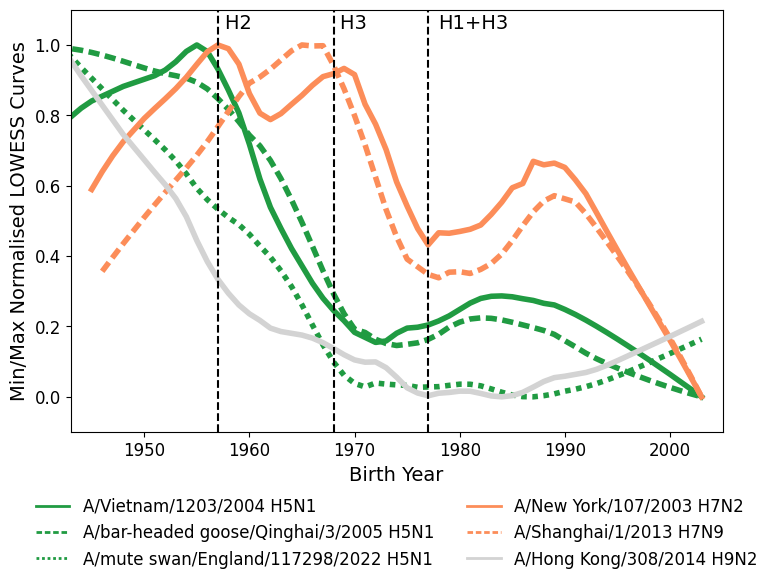

In [ ]:
year_columns = [
    "2004_Vietnam_H5",
    "2005_Qinghai_H5",
    "2022_H5",
    "2003_H7",
    "2013_H7",
    "2014_H9",
]

virus_colors = {
    "2004_Vietnam_H5": "#209b42",
    "2005_Qinghai_H5": "#209b42",
    "2022_H5": "#209b42",
    "2003_H7": "#fc8d59",
    "2013_H7": "#fc8d59",
    "2014_H9": "#D3D3D3",
}

line_styles = [
    "-",
    (0, (2, 1)),
    (0, (1, 1)),
    "-",
    (0, (2, 1)),
]

plt.figure(figsize=figsize)

for idx, virus in enumerate(year_columns):

    if virus not in merged_df.columns:
        continue
    
    valid = merged_df[
        [virus, "Birth_Year"]
    ].dropna()

    if valid.empty:
        continue

    color = virus_colors.get(
        virus,
        "grey",
    )
    # Fit LOWESS curve (no normalization)
    lowess_curve = lowess(
        valid[virus],
        valid["Birth_Year"],
        frac=0.4,
    )

    loess_x = lowess_curve[:, 0]
    loess_y = lowess_curve[:, 1]

    # Min/max normalise the curves
    y_min = loess_y.min()
    y_max = loess_y.max()

    if y_max > y_min:
        loess_y_norm = (
            loess_y - y_min
        ) / (
            y_max - y_min
        )
    else:
        loess_y_norm = loess_y

    plt.plot(
        loess_x,
        loess_y_norm,
        label=virus_labels.get(
            virus,
            virus,
        ),
        color=color,
        linewidth=4,
        linestyle=line_styles[
            idx % len(line_styles)
        ],
    )


plt.xlabel(
    "Birth Year",
    fontsize=label_fontsize,
)

plt.ylabel(
    "Min/Max Normalised LOWESS Curves",
    fontsize=label_fontsize,
)

legend = plt.legend(
    fontsize=legend_fontsize,
    frameon=legend_frameon,
    loc=legend_loc,
    bbox_to_anchor=legend_bbox,
    ncol=legend_ncol,
)

for legline in legend.get_lines():
    legline.set_linewidth(2)

plt.ylim(-0.1, 1.1)

plt.xticks(
    fontsize=tick_fontsize
)

plt.yticks(
    fontsize=tick_fontsize
)

plt.xlim(1943, 2005)

# Add vertical lines at specified birth years with labels
birth_years = {
    1957: "H2        ",
    1968: "H3        ",
    1977: "H1+H3",
}

for year, label in birth_years.items():
    plt.axvline(
        x=year,
        color="black",
        linestyle="--",
    )
    plt.text(
        year + 4.3,
        plt.ylim()[1] - 0.01,
        label,
        rotation=0,
        verticalalignment="top",
        fontsize=label_fontsize,
        ha="center",
    )

plt.tight_layout()
plt.show()

## H1/H3 normalised curves
Need to change year_columns to the H1 or the H3 option, as well as the name of the output file

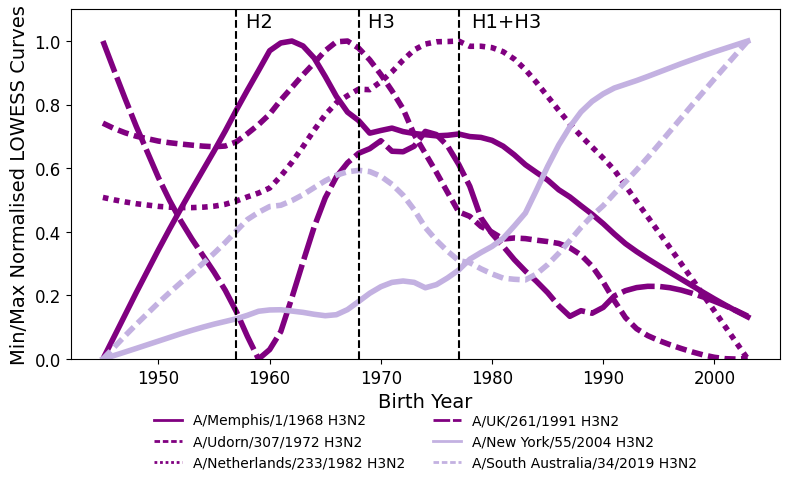

In [9]:
year_columns = ["1968_H3", "1972_H3", "1982_H3", "1991_H3", "2004_H3", "2019_H3"] # H3s
#year_columns = ['1918_H1', '1934_H1', '1977_H1', '2006_H1'] # H1s

virus_colors = {
    "1918_H1": "#084594",
    "1934_H1": "#084594",
    "1977_H1": "#9ecae1",
    "2006_H1": "#084594",
    "1968_H3": "purple",
    "1972_H3": "purple",
    "1982_H3": "purple",
    "1991_H3": "purple",
    "2004_H3": "#C3B1E1",
    "2019_H3": "#C3B1E1",
    "2004_Vietnam_H5": "#006d2c",
    "2005_Qinghai_H5": "#74c476",
    "2022_H5": "#c7e9c0",
    "2014_H9": "grey",
    "1966_H2": "red",
    "2003_H7": "#fdcc8a",
    "2013_H7": "#fc8d59",
}

linestyle_dict = {
    "1918_H1": "solid",
    "1934_H1": (0, (2, 1)),
    "1977_H1": "solid",
    "2006_H1": (0, (1, 1)),
    "1968_H3": "solid",
    "1972_H3": (0, (2, 1)),
    "1982_H3": (0, (1, 1)),
    "1991_H3": (0, (6, 1)),
    "2004_H3": "solid",
    "2019_H3": (0, (2, 1)),
    "2004_Vietnam_H5": "solid",
    "2005_Qinghai_H5": "solid",
    "2022_H5": "solid",
    "2003_H7": "dashed",
    "2013_H7": "dashed",
    "2014_H9": (0, (1, 1)),
}


plt.figure(figsize=(8, 5))

x = merged_df["Birth_Year"]

for year in year_columns:

    y = merged_df[year]

    valid_idx = (
        x.notna()
        & y.notna()
    )

    x_filtered = x[valid_idx]
    y_filtered = y[valid_idx]

    loess_curve = sm.nonparametric.lowess(
        y_filtered,
        x_filtered,
        frac=0.4,
    )

    loess_y = loess_curve[:, 1]

    loess_y_normalized = (
        loess_y - loess_y.min()
    ) / (
        loess_y.max()
        - loess_y.min()
    )

    plt.plot(
        loess_curve[:, 0],
        loess_y_normalized,
        label=virus_labels[year],
        color=virus_colors[year],
        linewidth=4,
        linestyle=linestyle_dict.get(
            year,
            "solid",
        ),
    )


plt.xlabel(
    "Birth Year",
    fontsize=14,
)

plt.ylabel(
    "Min/Max Normalised LOWESS Curves",
    fontsize=14,
)

legend = plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncol=2,
)

for legline in legend.get_lines():
    legline.set_linewidth(2)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, 1.1)

# Add vertical lines at specified birth years with labels
birth_years = {
    1957: "H2        ",
    1968: "H3        ",
    1977: "H1+H3",
}

for year, label in birth_years.items():
    plt.axvline(
        x=year,
        color="black",
        linestyle="--",
    )
    plt.text(
        year + 4.3,
        plt.ylim()[1] - 0.01,
        label,
        rotation=0,
        verticalalignment="top",
        fontsize=14,
        ha="center",
    )

plt.tight_layout()

# Need to change to H1/H3_Lowess
plt.savefig(
    OUTPUT_DIR / "H3_Lowess.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 95% confidence intervals

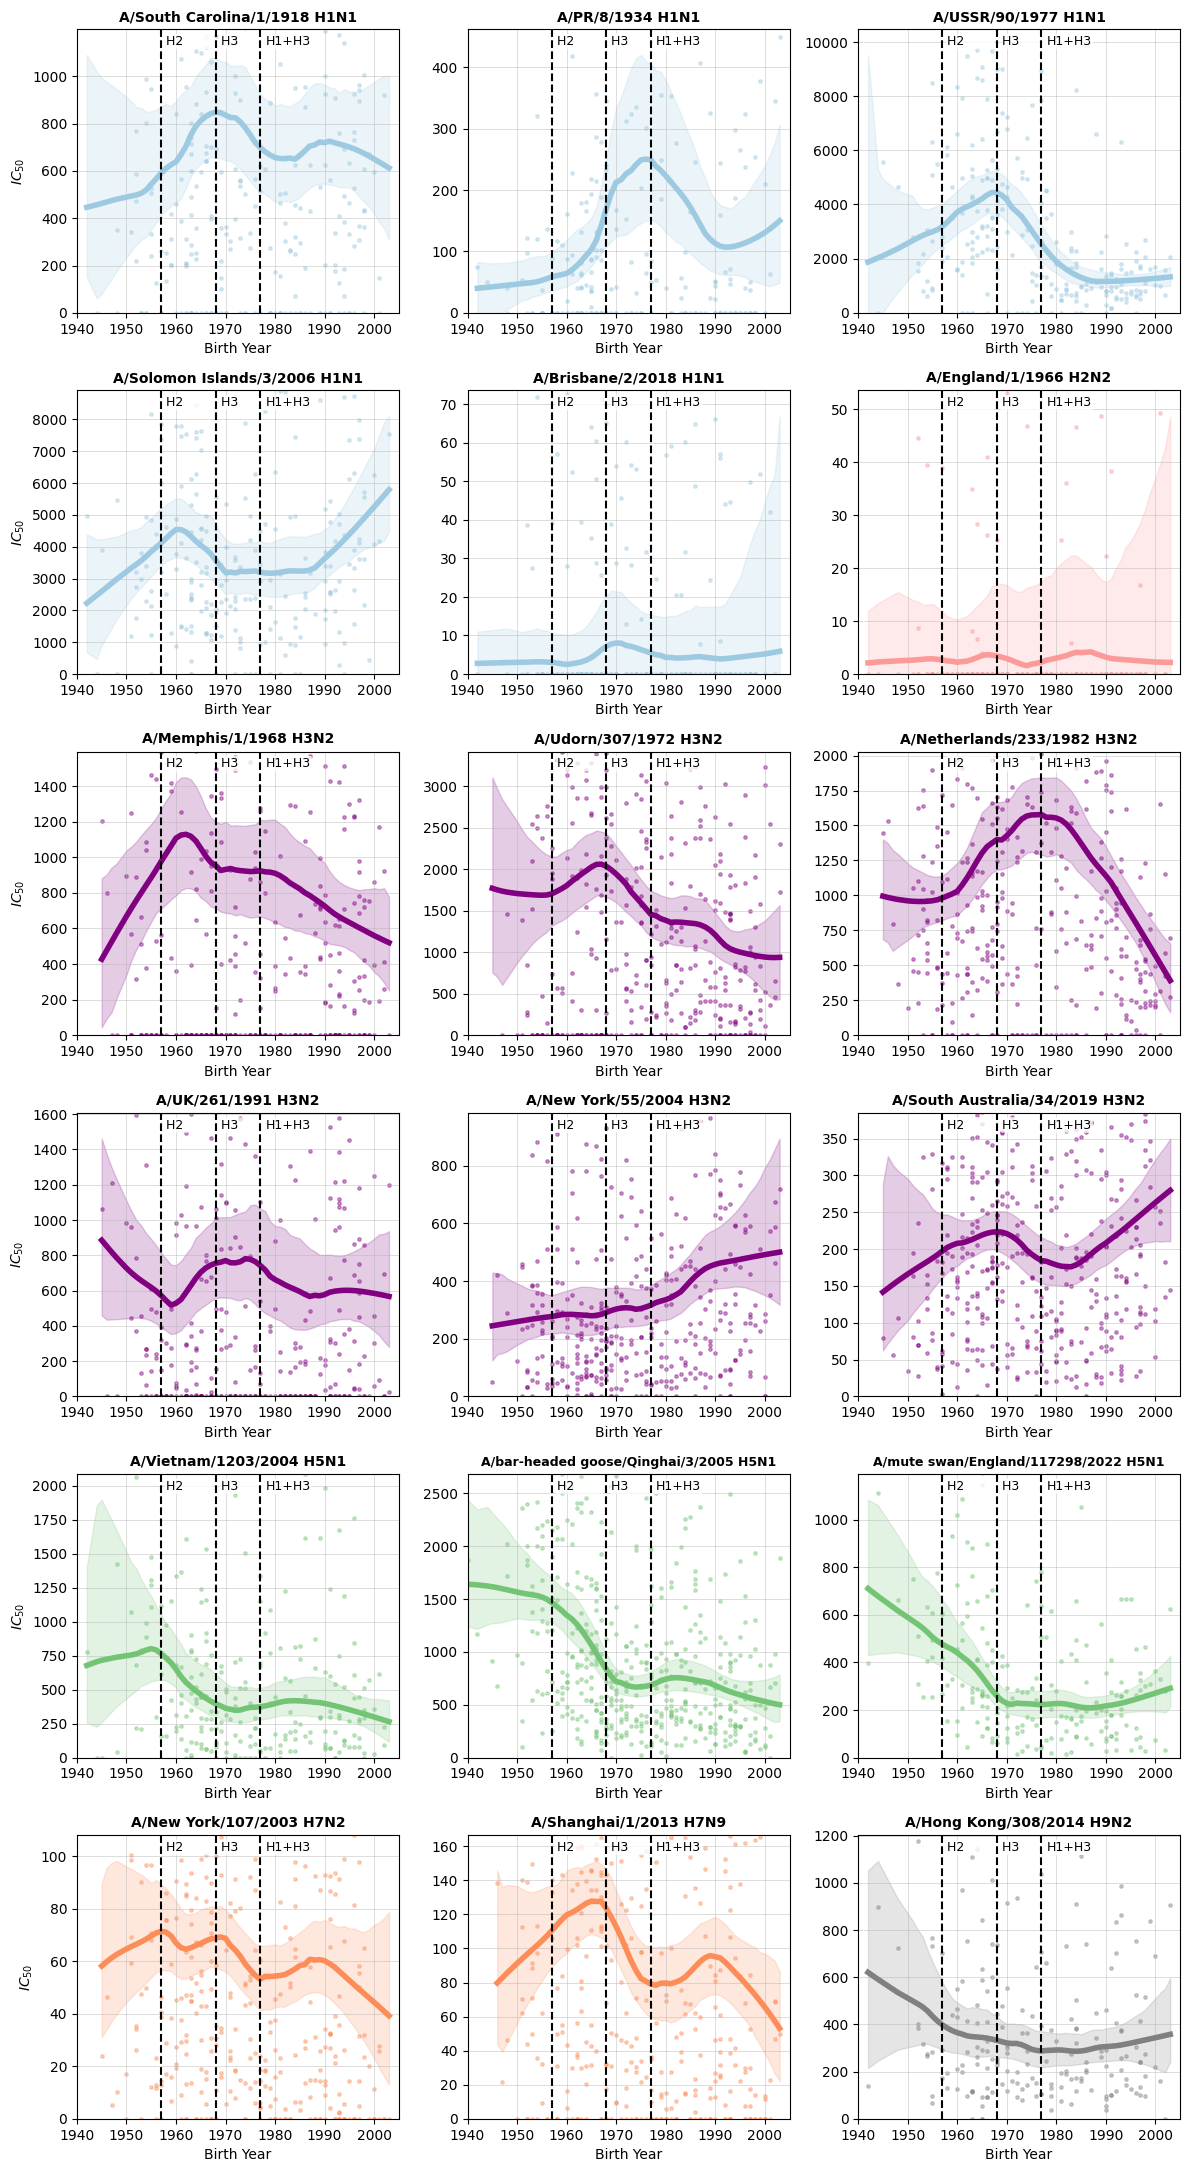

In [ ]:
virus_columns = viruses

colors_darker = [
    get_pastel_color(
        virus,
        darker_colors,
    )
    for virus in virus_columns
]

n_viruses = len(virus_columns)

n_cols = 3

n_rows = math.ceil(
    n_viruses / n_cols
)

fig, axes = plt.subplots(
    n_rows + 1,
    n_cols,
    figsize=(12, 25),
    sharey=False,
    sharex=False,
)

axes = axes.flatten()

for j in range(
    n_viruses,
    len(axes),
):
    fig.delaxes(axes[j])

fraction = 0.4
bootstrap_iterations = 500

for i, virus in enumerate(
    virus_columns
):

    ax = axes[i]

    ax.grid(
        True,
        which="both",
        axis="both",
        linestyle="-",
        linewidth=0.5,
        alpha=0.6,
    )

    valid = merged_df[
        ["Birth_Year", virus]
    ].dropna()

    if valid.empty:
        continue

    x_values = valid[
        "Birth_Year"
    ].values

    y_values = valid[
        virus
    ].values

    smoothed = lowess(
        y_values,
        x_values,
        frac=fraction,
        return_sorted=True,
    )

    x_smooth = smoothed[:, 0]
    y_smooth = smoothed[:, 1]

    y_bootstrap = np.zeros(
        (
            bootstrap_iterations,
            len(x_smooth),
        )
    )

    for j in range(
        bootstrap_iterations
    ):

        idx = rng.choice(
            len(x_values),
            size=len(x_values),
            replace=True,
        )

        x_resampled = x_values[idx]
        y_resampled = y_values[idx]

        smoothed_bootstrap = lowess(
            y_resampled,
            x_resampled,
            frac=fraction,
            return_sorted=True,
        )

        y_bootstrap[j, :] = np.interp(
            x_smooth,
            smoothed_bootstrap[:, 0],
            smoothed_bootstrap[:, 1],
            left=np.nan,
            right=np.nan,
        )

    lower_bound = np.nanpercentile(
        y_bootstrap,
        2.5,
        axis=0,
    )

    upper_bound = np.nanpercentile(
        y_bootstrap,
        97.5,
        axis=0,
    )

    ax.scatter(
        x_values,
        y_values,
        color=colors_darker[i],
        alpha=0.4,
        label="Data",
        s=6,
    )

    ax.plot(
        x_smooth,
        y_smooth,
        color=colors_darker[i],
        label="LOESS",
        linewidth=4,
        alpha=1,
    )

    ax.fill_between(
        x_smooth,
        lower_bound,
        upper_bound,
        color=colors_darker[i],
        alpha=0.2,
        label="95% CI",
    )

    ax.set_xlabel("Birth Year")

    ax.set_title(
        virus_labels[virus],
        fontweight="bold",
        fontsize=10,
    )

    if i % n_cols == 0:
        ax.set_ylabel("$IC_{50}$")

    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

    ymax = np.nanmax(upper_bound)

    ax.set_ylim(0, ymax * 1.1,)

    ax.set_xlim(1940, 2005,)

    if virus in [
        "2005_Qinghai_H5",
        "2022_H5",
    ]:
        ax.title.set_fontsize(9)

    birth_years = {
        1957: "H2       ",
        1968: "H3       ",
        1977: "H1+H3",
    }

    for year, label in birth_years.items():

        ax.text(
            year + 5.6,
            ax.get_ylim()[1] * 0.98,
            label,
            rotation=0,
            verticalalignment="top",
            fontsize=9,
            ha="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                boxstyle="round,pad=0.1",
                alpha=0.8,
            ),
        )

        ax.axvline(
            x=year,
            color="black",
            linestyle="--",
            zorder=10,
        )


plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "allLOWESS.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Age buckets

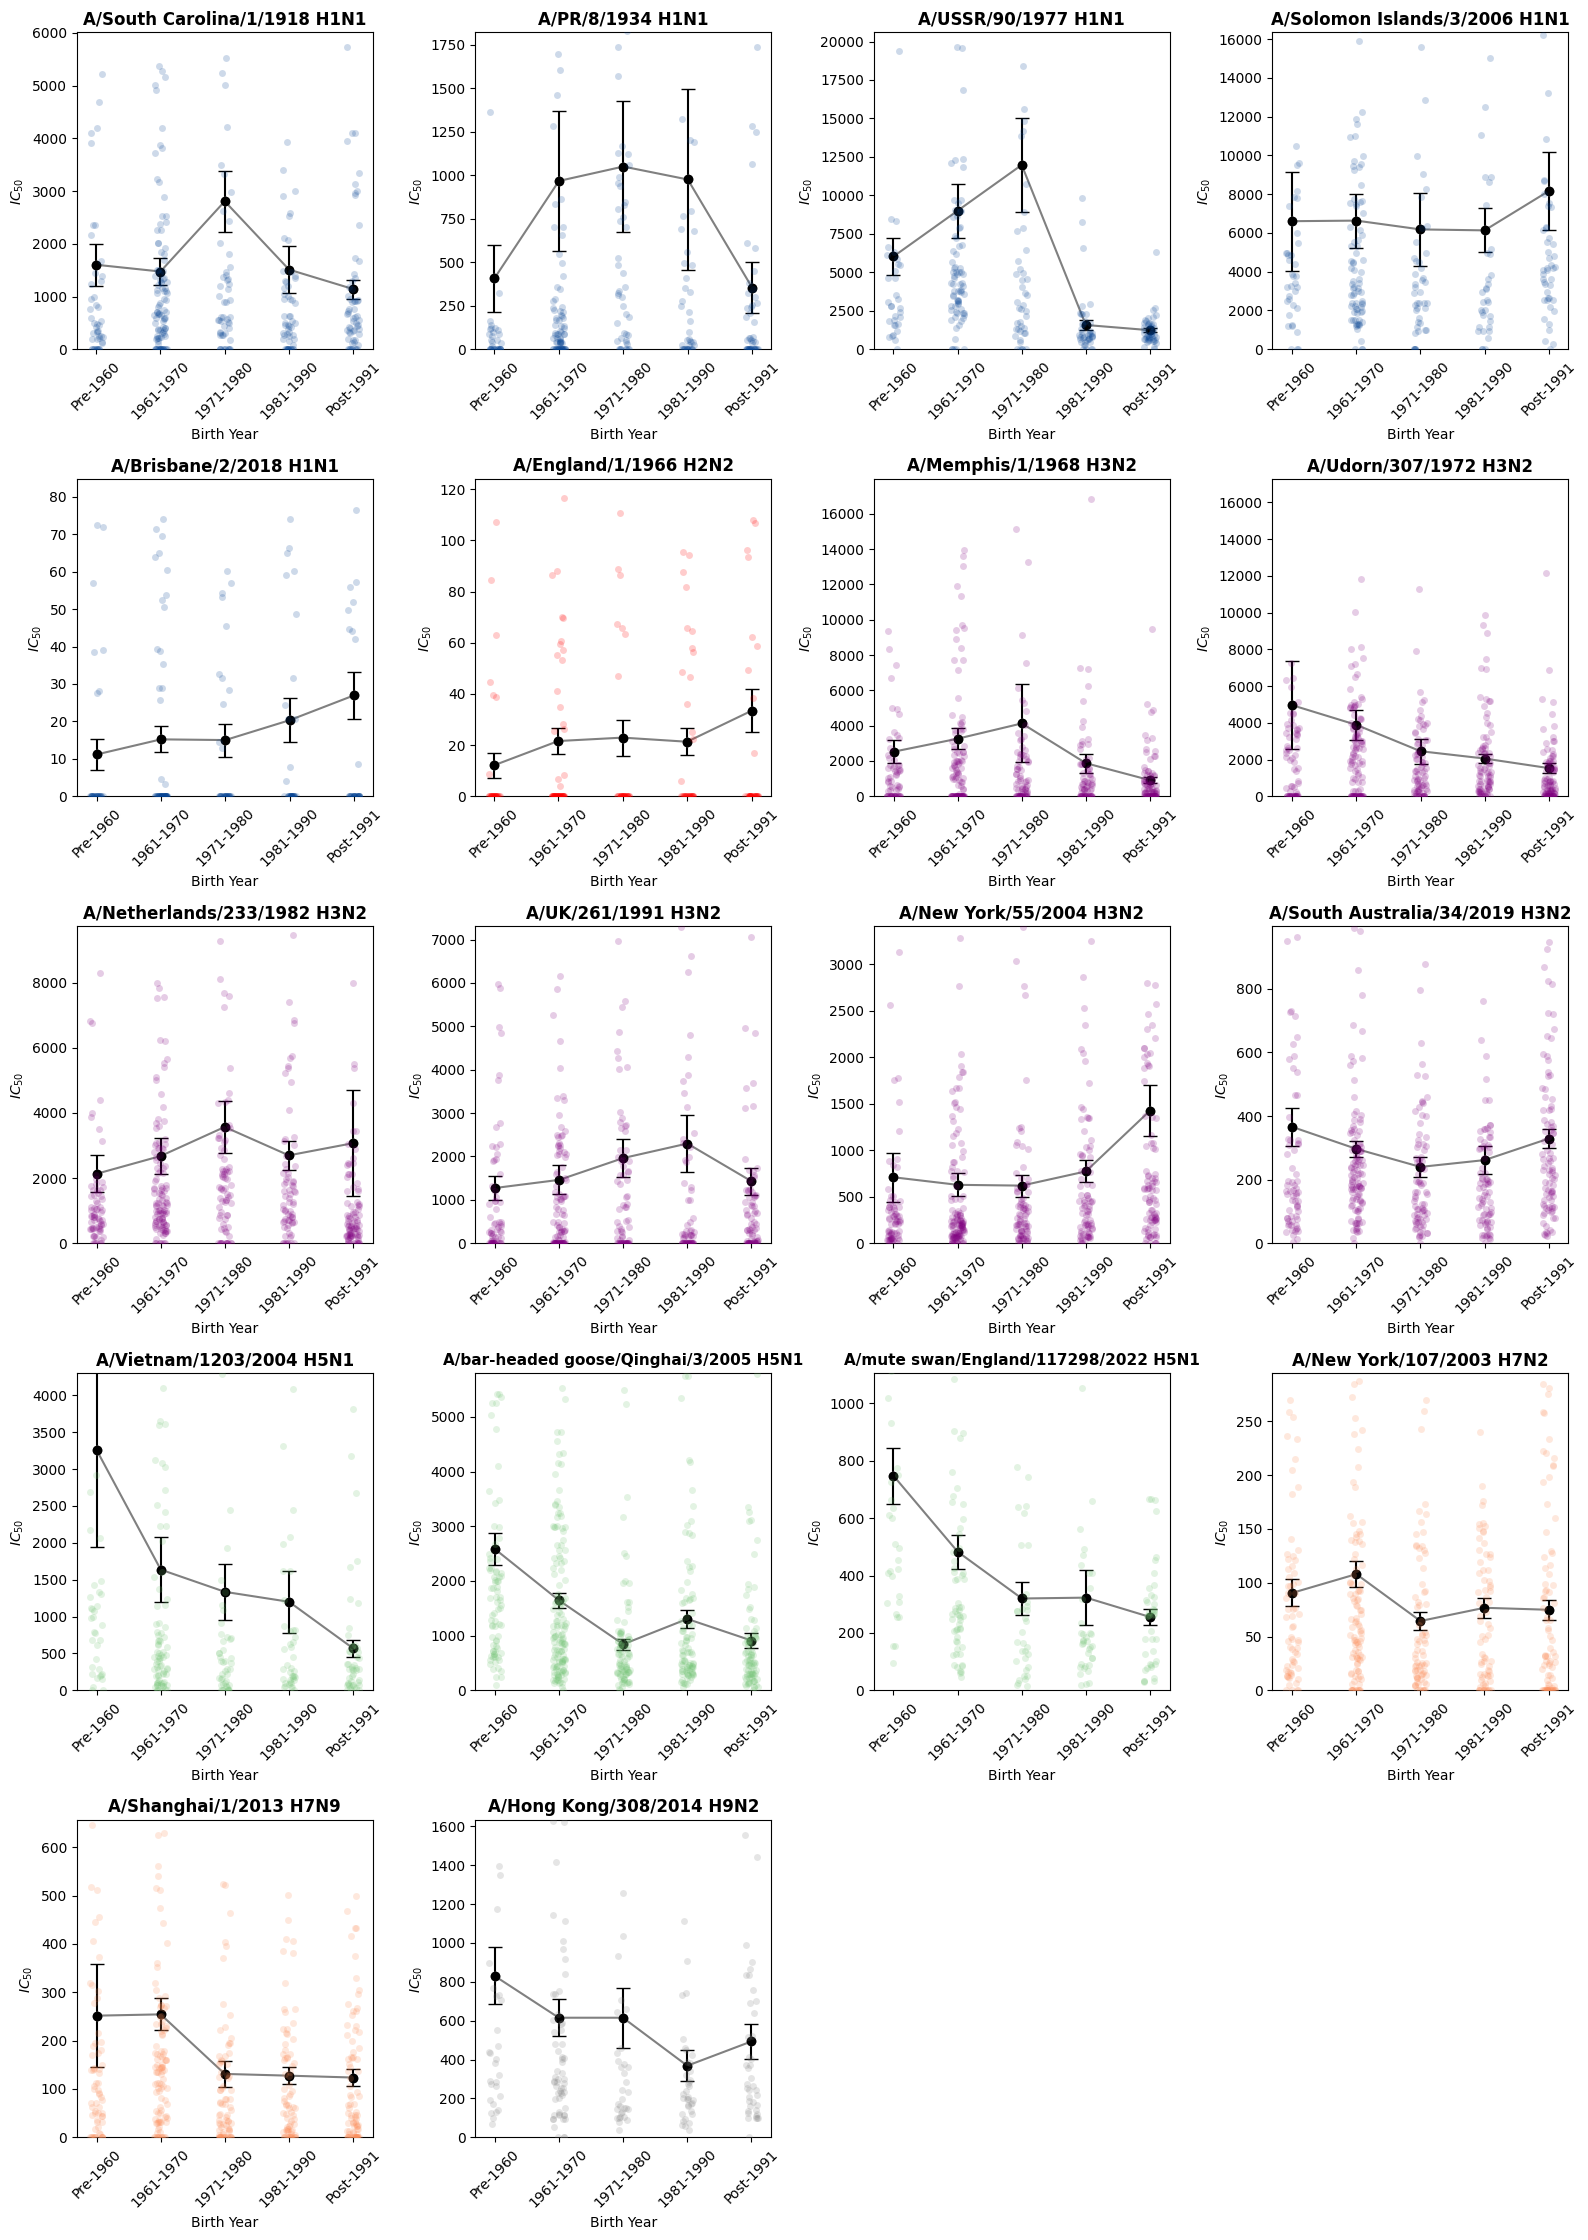


ALL FIGURES COMPLETE


In [ ]:
df = merged_df.copy()

# Define new age bins and labels
bins = [0,30,40,50,60,float("inf"),]

labels = [
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60+",
]

# Add an Age_Group column based on the defined bins and labels
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False,
)

# Reverse the order of age groups
df["Age_Group"] = pd.Categorical(
    df["Age_Group"],
    categories=labels[::-1],
    ordered=True,
)

# Update the age group labels
df["Age_Group"] = (
    df["Age_Group"]
    .cat.rename_categories(
        {
            "60+": "Pre-1960",
            "50-59": "1961-1970",
            "40-49": "1971-1980",
            "30-39": "1981-1990",
            "20-29": "Post-1991",
        }
    )
)

# List of viruses by group
viruses_h3 = ["1968_H3", "1972_H3", "1982_H3", "1991_H3", "2004_H3", "2019_H3",]
viruses_h7 = ["2003_H7", "2013_H7",]
viruses_h1 = ["1918_H1", "1934_H1", "1977_H1", "2006_H1", "2018_H1",]
viruses_h2 = ["1966_H2",]
viruses_h5 = ["2004_Vietnam_H5", "2005_Qinghai_H5", "2022_H5",]
viruses_h9 = ["2014_H9",]

# Panel settings
# Combine all viruses into a single list with their group and color
all_viruses = (
    [(v, "H1", "#084594")
        for v in viruses_h1]
    + [(v, "H2", "red")
        for v in viruses_h2]
    + [(v, "H3", "purple")
        for v in viruses_h3]
    + [(v, "H5", "#74c476")
        for v in viruses_h5]
    + [(v, "H7", "#fc8d59")
        for v in viruses_h7]
    + [(v, "H9", "grey")
        for v in viruses_h9]
)

n_viruses = len(all_viruses)
ncols = 4
nrows = (
    n_viruses + ncols - 1
) // ncols

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(
        4 * ncols,
        4.5 * nrows,
    ),
)

axes = axes.flatten()

for i, (
    virus,
    group,
    color,
) in enumerate(all_viruses):
    
    # Recalculate mean and SEM for the selected virus grouped by Age_Group
    mean_values = (
        df
        .groupby(
            "Age_Group",
            observed=False,
        )[virus]
        .mean()
    )

    sem_values = (
        df
        .groupby(
            "Age_Group",
            observed=False,
        )[virus]
        .apply(
            sem,
            nan_policy="omit",
        )
    )

    # Exclude the 10 highest values from the stripplot
    # For visualisation purposes
    filtered_df = df.copy()

    highest_values = (
        filtered_df[virus]
        .nlargest(10)
        .values
    )

    filtered_df[virus] = (
        filtered_df[virus]
        .apply(
            lambda x:
            np.nan
            if x in highest_values
            else x
        )
    )

     # Plot the mean values as points and connect them with a line
    sns.stripplot(
        data=filtered_df,
        x="Age_Group",
        y=virus,
        jitter=True,
        color=color,
        alpha=0.2,
        ax=axes[i],
    )

    axes[i].errorbar(
        mean_values.index,
        mean_values,
        yerr=sem_values,
        fmt="o",
        color="black",
        label="Mean IC50 ± SEM",
        capsize=5,
    )

    axes[i].plot(
        mean_values.index,
        mean_values,
        color="grey",
        linestyle="-",
        marker="o",
        label="Mean IC50",
    )

    axes[i].set_title(
        virus_labels[virus],
        fontweight="bold",
        fontsize=12,
    )

    if virus in [
        "2005_Qinghai_H5",
        "2022_H5",
    ]:
        axes[i].title.set_fontsize(11)

    axes[i].set_xlabel("Birth Year")

    axes[i].set_ylabel("$IC_{50}$")

    axes[i].tick_params(
        axis="x",
        rotation=45,
    )

    top = np.sort(
        df[virus].dropna()
    )[::-1]

    if virus in [ "1968_H3", "1972_H3", "2018_H1", "1966_H2",]:
        n = 10
    else:
        n = 20

    if len(top) >= max(n, 50):

        axes[i].set_ylim(
            0,
            top[n - 1] * 1.05,
        )

    elif len(top) > 0:
        axes[i].set_ylim(0, top[-1] * 1.05,)

    else:
        axes[i].set_ylim(0, 1,)

for j in range(i + 1, len(axes),):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "AgeBuckets.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\n" + "=" * 70)
print("ALL FIGURES COMPLETE")
print("=" * 70)